# Mini Projet Préparation de Données Images
Classification de déchets : cardboard, glass, metal, paper, plastic, trash

Objectif : construire un jeu de données images propre et homogène à partir d'images brutes hétérogènes.

## Configuration et structure du projet

In [1]:
# Question 0 - Import des librairies
import os
import shutil
import hashlib
import numpy as np
import pandas as pd
from PIL import Image, ImageStat
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [6]:
# Question 0 - Définition des chemins et création des dossiers du projet
BASE_DIR = ".."
RAW_DIR = os.path.join(BASE_DIR, "data", "raw")
CLEANED_DIR = os.path.join(BASE_DIR, "data", "cleaned")
REPORTS_DIR = os.path.join(BASE_DIR, "reports")

CLASSES = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]

for classe in CLASSES:
    os.makedirs(os.path.join(CLEANED_DIR, classe), exist_ok=True)

print("Dossiers prêts.")


Dossiers prêts.


## Partie 1 – Exploration du dataset

In [25]:
# Question 1 - Récupérer pour chaque image : nom, classe, format, mode,
# largeur, hauteur, ecart-type des pixels, nombre de canaux, taille (poids)

def explorer_image(chemin, classe):
    infos={
        "nom":os.path.basename(chemin),
        "classe":classe,
        "chemin": chemin,
        "format":None,
        "mode":None,
        "largeur":None,
        "hauteur":None,
        "ecart_type":None,
        "nb_canaux":None,
        "taille_octets":os.path.getsize(chemin),
        "corrompue":False
    }
    try:
        with Image.open(chemin) as img:
            img.verify()  # Vérifie si l'image est corrompue
        with Image.open(chemin) as img:
            infos["format"]=img.format
            infos["mode"]=img.mode
            infos["largeur"], infos["hauteur"]=img.size
            if img.mode=="L":
                infos["nb_canaux"]=1
            else:
                infos["nb_canaux"]=len(img.getbands())
            stat=ImageStat.Stat(img.convert("L"))
            infos["ecart_type"]=stat.stddev[0]
    except Exception:
            infos["corrompue"]=True
    return infos


In [26]:
lignes = []
for classe in CLASSES:
    dossier_classe = os.path.join(RAW_DIR, classe)
    if not os.path.isdir(dossier_classe):
        continue
    for nom_fichier in os.listdir(dossier_classe):
        chemin = os.path.join(dossier_classe, nom_fichier)
        if os.path.isfile(chemin):
            lignes.append(explorer_image(chemin, classe))

df = pd.DataFrame(lignes)
print("Nombre total d'images explorées :", len(df))
df.head()

Nombre total d'images explorées : 1032


,nom,classe,chemin,format,mode,largeur,hauteur,ecart_type,nb_canaux,taille_octets,corrompue
0,cardboard1.jpg,cardboard,..\data\raw\cardboard\cardboard1.jpg,JPEG,RGB,512.0,384.0,31.875892,3.0,17333,False
1,cardboard10.jpg,cardboard,..\data\raw\cardboard\cardboard10.jpg,JPEG,RGB,512.0,384.0,38.799907,3.0,21683,False
2,cardboard100.jpg,cardboard,..\data\raw\cardboard\cardboard100.jpg,JPEG,RGB,512.0,384.0,44.498372,3.0,14884,False
3,cardboard101.jpg,cardboard,..\data\raw\cardboard\cardboard101.jpg,JPEG,RGB,512.0,384.0,68.561937,3.0,14289,False
4,cardboard102.jpg,cardboard,..\data\raw\cardboard\cardboard102.jpg,JPEG,RGB,512.0,384.0,45.320633,3.0,18015,False


## Partie 2 – Détecter les images corrompues

In [27]:
# Question 2 - Fonction de détection d'image corrompue
def est_corrompue(chemin):
    try:
        with Image.open(chemin) as img:
            img.verify()
        return False
    except Exception:
        return True

In [28]:
df_corrompues=df[df["corrompue"]==True]
print("Nombre d'images corrompues :", len(df_corrompues))
df_corrompues[["nom", "classe"]]

Nombre d'images corrompues : 6


,nom,classe
147,cardboard83.jpg,cardboard
326,glass74.jpg,glass
446,metal48.jpg,metal
633,paper213.jpg,paper
791,plastic13.jpg,plastic
1004,trash3.jpg,trash


## Partie 3 – Détecter les images vides

In [29]:
# Question 3 - Fonction de détection d'image vide (noire, blanche ou peu de variation)
SEUIL_VARIATION = 5.0

def est_vide(chemin, seuil=SEUIL_VARIATION):
    try:
        with Image.open(chemin) as img:
            stat = ImageStat.Stat(img.convert("L"))
            moyenne = stat.mean[0]
            ecart_type = stat.stddev[0]
            if ecart_type < seuil:
                return True
            if moyenne < 5 or moyenne > 250:
                return True
            return False
    except Exception:
        return False

df_non_corrompues = df[df["corrompue"] == False].copy()
df_non_corrompues["vide"] = df_non_corrompues["chemin"].apply(est_vide)

df_vides = df_non_corrompues[df_non_corrompues["vide"] == True]
print("Nombre d'images quasi vides :", len(df_vides))
df_vides[["nom", "classe"]]

Nombre d'images quasi vides : 4


,nom,classe
167,image-blanche-512x384.jpg,cardboard
355,image-noire-512x384.png,glass
357,image-blanche-512x384.jpg,metal
358,image-noire-512x384.png,metal


## Partie 4 – Détecter les différences de résolution

In [31]:
# Question 4.1 - Résolution min, max, les plus fréquentes et nombre d'images par résolution

df_valides=df_non_corrompues[df_non_corrompues["vide"]==False].copy()
df_valides["resolution"]=df_valides["largeur"].astype(str) + "x" + df_valides["hauteur"].astype(str)

resolution_min=(df_valides["largeur"].min(), df_valides["hauteur"].min())
resolution_max=(df_valides["largeur"].max(), df_valides["hauteur"].max())
compte_resolutions=df_valides["resolution"].value_counts()

print("Résolution minimale :", resolution_min)
print("Résolution maximale :", resolution_max)
print("\nRésolutions les plus fréquentes :")
compte_resolutions.head(10)


Résolution minimale : (np.float64(32.0), np.float64(32.0))
Résolution maximale : (np.float64(512.0), np.float64(384.0))

Résolutions les plus fréquentes :


resolution
512.0x384.0    1009
32.0x32.0         5
48.0x32.0         4
40.0x40.0         4
Name: count, dtype: int64

In [32]:
# Question 4.2 - Images ne respectant pas la contrainte 64x64 minimum
TAILLE_MIN=64

df_trop_petites=df_valides[(df_valides["largeur"] < TAILLE_MIN) | (df_valides["hauteur"] < TAILLE_MIN)]
print("Nombre d'images trop petites (< 64x64) :", len(df_trop_petites))
df_trop_petites[["nom", "classe", "largeur", "hauteur"]]

Nombre d'images trop petites (< 64x64) : 13


,nom,classe,largeur,hauteur
20,cardboard117.jpg,cardboard,48.0,32.0
77,cardboard22.jpg,cardboard,32.0,32.0
133,cardboard70.jpg,cardboard,40.0,40.0
171,glass100.jpg,glass,40.0,40.0
229,glass15.jpg,glass,48.0,32.0
268,glass21.jpg,glass,32.0,32.0
270,glass23.jpg,glass,32.0,32.0
383,metal121.jpg,metal,48.0,32.0
413,metal2.jpg,metal,32.0,32.0
421,metal26.jpg,metal,40.0,40.0


## Partie 5 – Détecter les différents canaux

In [33]:
# Question 5 - Nombre d'images selon leur nombre de canaux
compte_canaux = df_valides["nb_canaux"].value_counts()
print(compte_canaux)

nb_grayscale = int((df_valides["nb_canaux"] == 1).sum())
nb_rgba = int((df_valides["nb_canaux"] == 4).sum())
print("\nImages grayscale :", nb_grayscale)
print("Images RGBA :", nb_rgba)

nb_canaux
3.0    1004
4.0      16
1.0       2
Name: count, dtype: int64

Images grayscale : 2
Images RGBA : 16


## Partie 6 – Détecter les doublons

In [34]:
# Question 6 - Fonction de détection des doublons (basée sur le contenu de l'image, pas le nom du fichier)

def hash_image(chemin):
    try:
        with Image.open(chemin) as img:
            img_norm = img.convert("RGB").resize((64, 64))
            return hashlib.md5(img_norm.tobytes()).hexdigest()
    except Exception:
        return None

df_valides["hash"] = df_valides["chemin"].apply(hash_image)

doublons_mask = df_valides.duplicated(subset="hash", keep="first")
df_doublons = df_valides[doublons_mask]
print("Nombre de doublons détectés :", len(df_doublons))
df_doublons[["nom", "classe"]]

Nombre de doublons détectés : 13


,nom,classe
356,image-violet-512x384.gif,glass
388,metal125po.jpg,metal
432,metal35rt.jpg,metal
496,metal91.jpg,metal
505,metalyu65.jpg,metal
643,paper221kl.jpg,paper
732,paper77ty.jpg,paper
757,paperer35.jpg,paper
804,plastic140y.jpg,plastic
817,plastic152.jpg,plastic


## Partie 7 – Détecter les images mal classées

Contrôle visuel : on affiche un échantillon d'images de chaque classe pour repérer les erreurs de classement.

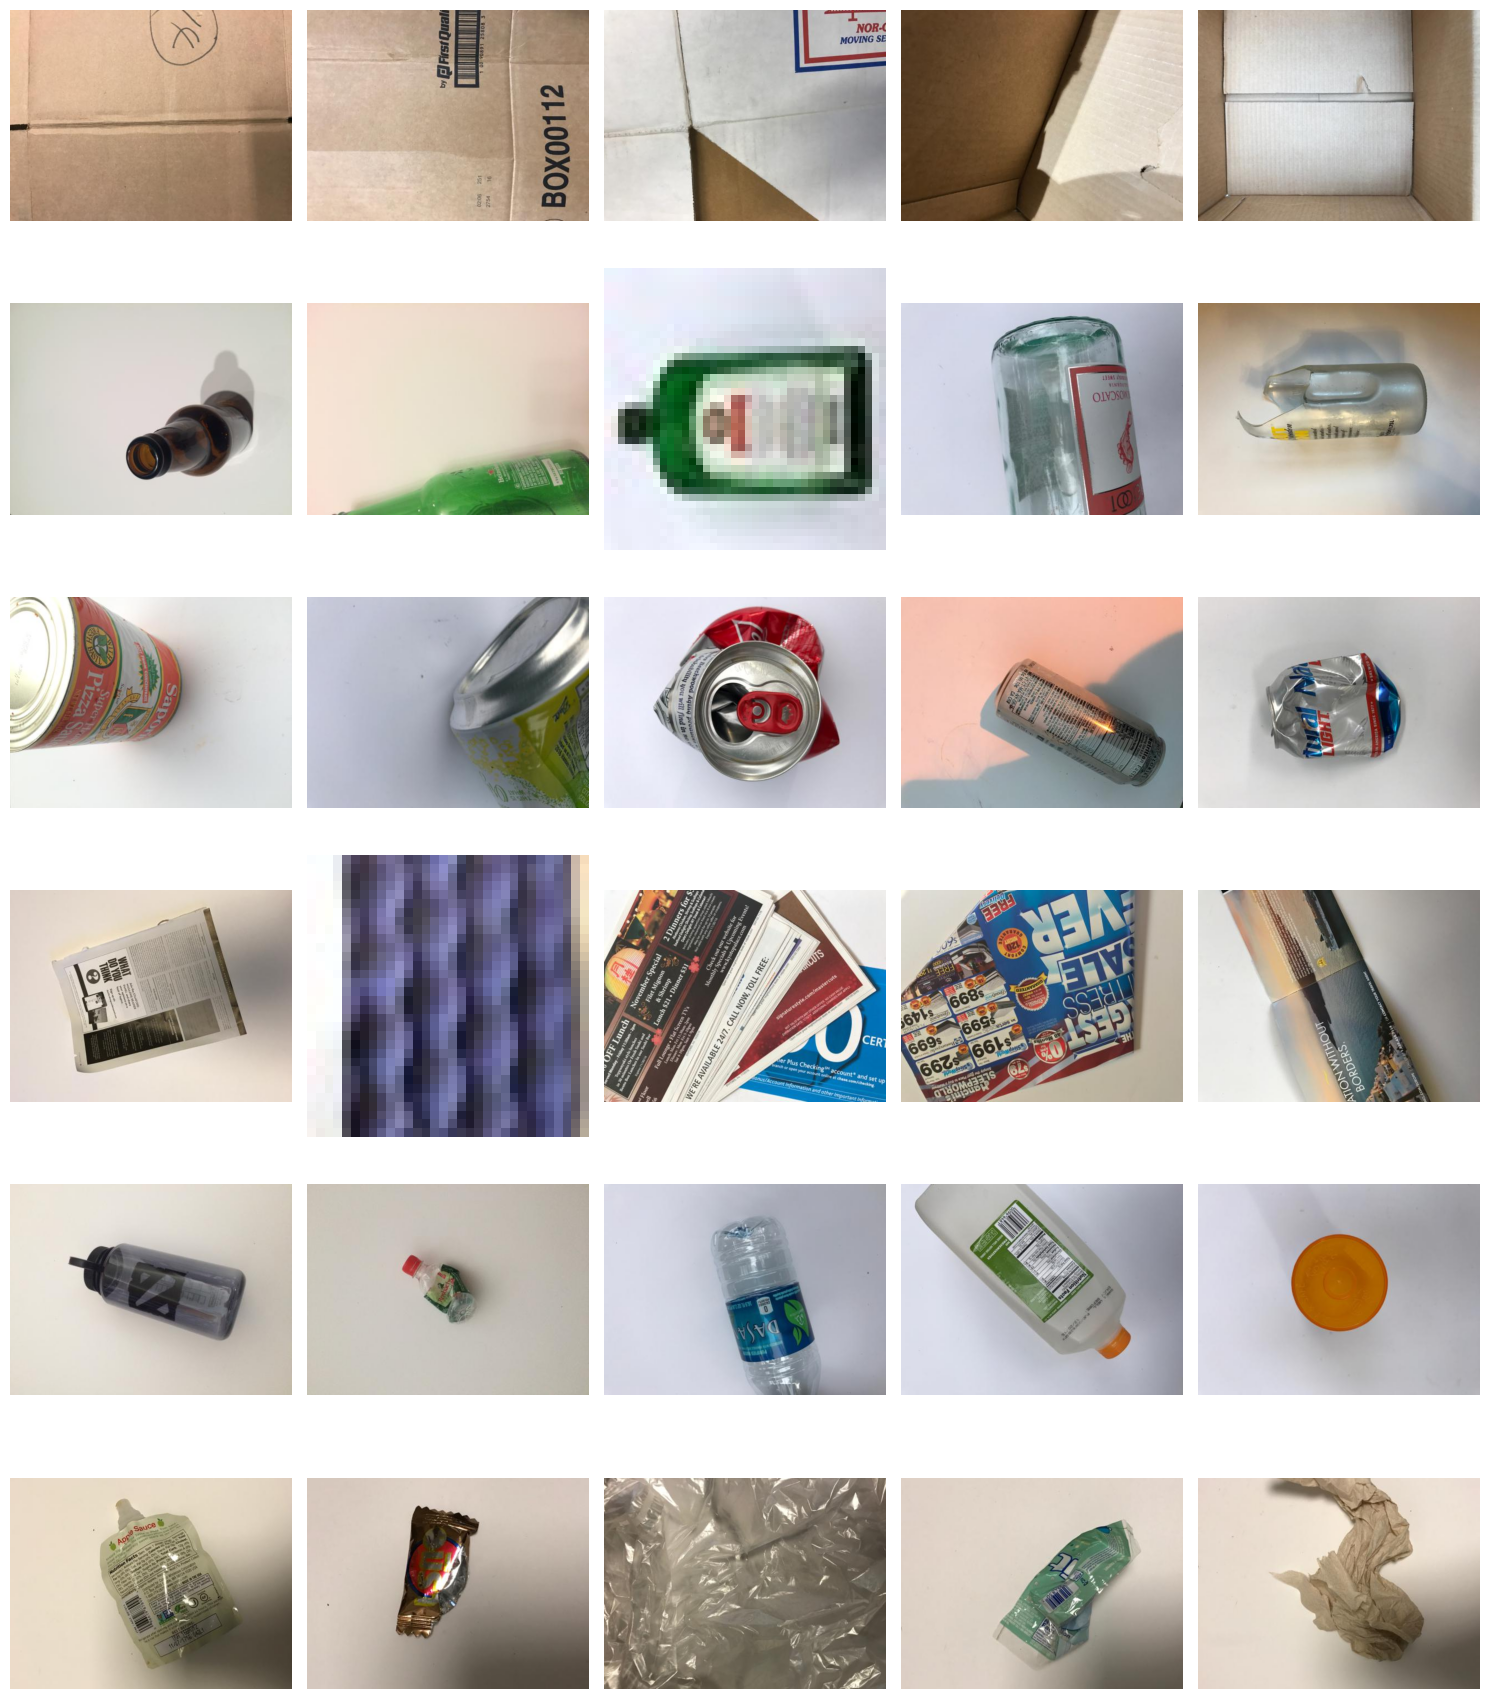

In [35]:
# Question 7 - Affichage d'un échantillon par classe pour contrôle visuel
NB_ECHANTILLON= 5

fig, axes=plt.subplots(len(CLASSES), NB_ECHANTILLON, figsize=(15, 3 * len(CLASSES)))

for i in range(len(CLASSES)):
    classe=CLASSES[i]
    sous_ensemble=df_valides[df_valides["classe"]==classe].head(NB_ECHANTILLON)
    chemins=sous_ensemble["chemin"].tolist()
    for j in range(NB_ECHANTILLON):
        ax=axes[i][j]
        if j < len(chemins):
            with Image.open(chemins[j]) as img:
                ax.imshow(img)
        ax.axis("off")
        if j==0:
            ax.set_ylabel(classe)

plt.tight_layout()
plt.show()

## Partie 8 – Analyser le déséquilibre des classes

classe
paper        251
plastic      223
glass        186
cardboard    167
metal        146
trash         49
Name: count, dtype: int64


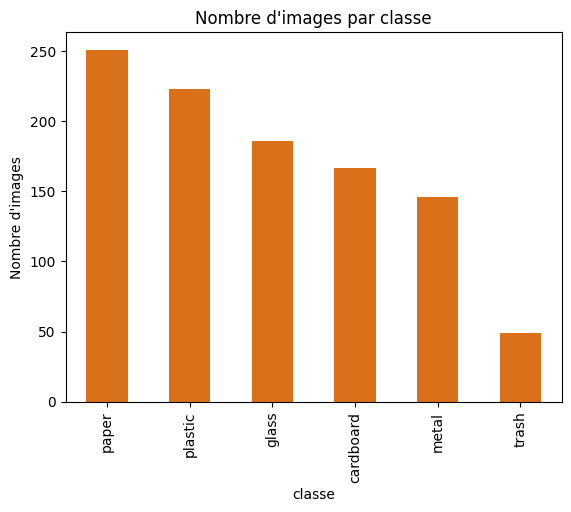


Classe minoritaire : trash


In [39]:
# # Question 8 - Nombre d'images par classe
compte_classes=df_valides["classe"].value_counts()
print(compte_classes)

compte_classes.plot(kind="bar", color="#d9711a", title="Nombre d'images par classe")
plt.ylabel("Nombre d'images")
plt.show()

classe_minoritaire=compte_classes.idxmin()
print("\nClasse minoritaire :", classe_minoritaire)

## Partie 9 – Redimensionnement

In [40]:
# Question 9 - Redimensionner toutes les images valides à 224x224 avec conservation
# des proportions et ajout de padding, puis sauvegarde dans data/cleaned

TAILLE_CIBLE = (224, 224)

def redimensionner_avec_padding(img, taille_cible=TAILLE_CIBLE):
    largeur_cible, hauteur_cible = taille_cible
    largeur, hauteur = img.size

    ratio = min(largeur_cible / largeur, hauteur_cible / hauteur)
    nouvelle_largeur = int(largeur * ratio)
    nouvelle_hauteur = int(hauteur * ratio)

    img_redim = img.resize((nouvelle_largeur, nouvelle_hauteur))

    fond = Image.new("RGB", taille_cible, (0, 0, 0))
    decalage_x = (largeur_cible - nouvelle_largeur) // 2
    decalage_y = (hauteur_cible - nouvelle_hauteur) // 2
    fond.paste(img_redim, (decalage_x, decalage_y))
    return fond

In [41]:
# Exclusion des doublons repérés en Partie 6
chemins_a_exclure = set(df_doublons["chemin"].tolist())

df_finales = df_valides[~df_valides["chemin"].isin(chemins_a_exclure)].copy()
print("Nombre d'images à traiter :", len(df_finales))

Nombre d'images à traiter : 1009


## Partie 10 – Uniformisation des canaux

In [42]:
# Question 10 - Conversion de toutes les images en RGB (fait pendant la sauvegarde ci-dessous)

chemins_cleaned = []
for index in df_finales.index:
    chemin = df_finales.loc[index, "chemin"]
    classe = df_finales.loc[index, "classe"]
    nom = df_finales.loc[index, "nom"]

    with Image.open(chemin) as img:
        img_rgb = img.convert("RGB")
        img_traitee = redimensionner_avec_padding(img_rgb)

        chemin_sortie = os.path.join(CLEANED_DIR, classe, nom)
        img_traitee.save(chemin_sortie)
        chemins_cleaned.append(chemin_sortie)

df_finales["chemin_cleaned"] = chemins_cleaned
print("Images redimensionnées et converties en RGB, sauvegardées dans data/cleaned.")

Images redimensionnées et converties en RGB, sauvegardées dans data/cleaned.


## Partie 11 – Mise à l'échelle des pixels

In [43]:
# Question 11 - Normalisation des valeurs de pixels (0-255 -> 0-1)

def charger_et_normaliser(chemin):
    with Image.open(chemin) as img:
        tableau = np.array(img, dtype=np.float32)
        tableau_normalise = tableau / 255.0
    return tableau_normalise

# Exemple de vérification sur une image
exemple_chemin = df_finales["chemin_cleaned"].iloc[0]
exemple_normalise = charger_et_normaliser(exemple_chemin)
print("Forme du tableau :", exemple_normalise.shape)
print("Valeur min :", exemple_normalise.min(), "- Valeur max :", exemple_normalise.max())

Forme du tableau : (224, 224, 3)
Valeur min : 0.0 - Valeur max : 0.9882353


## Partie 12 – Découpage Train / Validation / Test

In [44]:
# Question 12 - Découpage du dataset nettoyé en train (70%), validation (15%), test (15%)

train_df, temp_df = train_test_split(
    df_finales, test_size=0.3, stratify=df_finales["classe"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["classe"], random_state=42
)

print("Train :", len(train_df))
print("Validation :", len(val_df))
print("Test :", len(test_df))

for sous_ensemble, nom_ensemble in [(train_df, "train"), (val_df, "val"), (test_df, "test")]:
    for classe in CLASSES:
        dossier = os.path.join(CLEANED_DIR, nom_ensemble, classe)
        os.makedirs(dossier, exist_ok=True)
    for index in sous_ensemble.index:
        source = sous_ensemble.loc[index, "chemin_cleaned"]
        classe = sous_ensemble.loc[index, "classe"]
        nom = sous_ensemble.loc[index, "nom"]
        destination = os.path.join(CLEANED_DIR, nom_ensemble, classe, nom)
        shutil.copy(source, destination)

print("Découpage terminé.")

Train : 706
Validation : 151
Test : 152
Découpage terminé.


## Partie 13 – Data Augmentation

### Question 13.2 - Pourquoi éviter la data augmentation avant le découpage du dataset ?

Si l'augmentation est faite avant le découpage, des versions augmentées d'une même image
d'origine peuvent se retrouver à la fois dans le train et dans le test (ou la validation).
Le modèle "voit" alors indirectement des données de test pendant l'entraînement : c'est une
fuite de données (data leakage) qui fausse l'évaluation et donne une performance
artificiellement optimiste.

In [45]:
# Question 13.1 - Data augmentation avec Keras sur la classe minoritaire (train uniquement)

generateur_augmentation = ImageDataGenerator(
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    brightness_range=[0.85, 1.15]
)

dossier_classe_minoritaire = os.path.join(CLEANED_DIR, "train", classe_minoritaire)
dossier_sortie_augmentation = os.path.join(CLEANED_DIR, "train_augmente", classe_minoritaire)
os.makedirs(dossier_sortie_augmentation, exist_ok=True)

NB_IMAGES_A_GENERER = 200
compteur = 0

for nom_fichier in os.listdir(dossier_classe_minoritaire):
    if compteur >= NB_IMAGES_A_GENERER:
        break
    chemin = os.path.join(dossier_classe_minoritaire, nom_fichier)
    with Image.open(chemin) as img:
        tableau = np.expand_dims(np.array(img), axis=0)
        flux = generateur_augmentation.flow(
            tableau, batch_size=1,
            save_to_dir=dossier_sortie_augmentation,
            save_prefix="aug", save_format="jpg"
        )
        next(flux)
        compteur += 1

print("Images augmentées générées pour la classe minoritaire :", classe_minoritaire, "-", compteur)

Images augmentées générées pour la classe minoritaire : trash - 34


## Partie 14 – Bonus 1

Proposition : génération automatique du rapport d'audit `audit_images.csv` récapitulant
tous les indicateurs calculés dans l'atelier.

In [46]:
# Bonus - Génération du rapport d'audit final

rapport = {
    "total_images": [len(df)],
    "images_corrompues": [len(df_corrompues)],
    "images_quasi_vides": [len(df_vides)],
    "images_trop_petites": [len(df_trop_petites)],
    "doublons": [len(df_doublons)],
    "images_grayscale": [nb_grayscale],
    "images_rgba": [nb_rgba],
    "images_mal_classees": [len(images_mal_classees)]
}

df_rapport = pd.DataFrame(rapport)
chemin_rapport = os.path.join(REPORTS_DIR, "audit_images.csv")
df_rapport.to_csv(chemin_rapport, index=False)

print("Rapport d'audit sauvegardé :", chemin_rapport)
df_rapport

Rapport d'audit sauvegardé : ..\reports\audit_images.csv


,total_images,images_corrompues,images_quasi_vides,images_trop_petites,doublons,images_grayscale,images_rgba,images_mal_classees
0,1032,6,4,13,13,2,16,1


## Partie 14 Bonus 2 – Entraîner un modèle et le sauvegarder pour le web

On entraîne un CNN simple sur les images nettoyées (`cleaned/train`, `cleaned/val`, `cleaned/test`
générées en Partie 12), on l'évalue, puis on le sauvegarde avec le mapping des classes afin de
pouvoir le réutiliser dans une application (web par exemple) : donner une image en entrée,
le modèle renvoie la classe de déchet prédite.

In [51]:
# Bonus - Chargement des images depuis les dossiers train/val/test avec Keras

from tensorflow.keras.preprocessing.image import ImageDataGenerator

DOSSIER_TRAIN = os.path.join(CLEANED_DIR, "train")
DOSSIER_VAL = os.path.join(CLEANED_DIR, "val")
DOSSIER_TEST = os.path.join(CLEANED_DIR, "test")

generateur_train = ImageDataGenerator(rescale=1.0 / 255)
generateur_val = ImageDataGenerator(rescale=1.0 / 255)
generateur_test = ImageDataGenerator(rescale=1.0 / 255)

flux_train = generateur_train.flow_from_directory(
    DOSSIER_TRAIN, target_size=(224, 224), batch_size=32, class_mode="categorical"
)
flux_val = generateur_val.flow_from_directory(
    DOSSIER_VAL, target_size=(224, 224), batch_size=32, class_mode="categorical"
)
flux_test = generateur_test.flow_from_directory(
    DOSSIER_TEST, target_size=(224, 224), batch_size=32, class_mode="categorical"
)

# Mapping index -> nom de classe (utile plus tard pour interpréter la prédiction du modèle)
mapping_classes = {}
for nom_classe, index in flux_train.class_indices.items():
    mapping_classes[index] = nom_classe

print(mapping_classes)

Found 706 images belonging to 6 classes.
Found 150 images belonging to 6 classes.
Found 152 images belonging to 6 classes.
{0: 'cardboard', 1: 'glass', 2: 'metal', 3: 'paper', 4: 'plastic', 5: 'trash'}


In [54]:
# Construction d'un CNN simple

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

nb_classes = len(CLASSES)

modele = Sequential()
modele.add(Conv2D(32, (3, 3), activation="relu", input_shape=(224, 224, 3)))
modele.add(MaxPooling2D(2, 2))
modele.add(Conv2D(64, (3, 3), activation="relu"))
modele.add(MaxPooling2D(2, 2))
modele.add(Conv2D(128, (3, 3), activation="relu"))
modele.add(MaxPooling2D(2, 2))
modele.add(Flatten())
modele.add(Dense(128, activation="relu"))
modele.add(Dropout(0.3))
modele.add(Dense(nb_classes, activation="softmax"))


modele.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
modele.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [55]:
# Entraînement du modèle
NB_EPOCHS = 10

historique = modele.fit(
    flux_train,
    validation_data=flux_val,
    epochs=NB_EPOCHS
)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 23s 838ms/step - accuracy: 0.2394 - loss: 2.2447 - val_accuracy: 0.1467 - val_loss: 1.7233
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 18s 770ms/step - accuracy: 0.3059 - loss: 1.6262 - val_accuracy: 0.3800 - val_loss: 1.5025
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 818ms/step - accuracy: 0.3867 - loss: 1.5019 - val_accuracy: 0.4867 - val_loss: 1.3876
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 833ms/step - accuracy: 0.4235 - loss: 1.4142 - val_accuracy: 0.4200 - val_loss: 1.3865
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.4773 - loss: 1.2878 - val_accuracy: 0.4933 - val_loss: 1.2839
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 40s 939ms/step - accuracy: 0.5000 - loss: 1.1894 - val_accuracy: 0.4467 - val_loss: 1.3548
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.5637 - loss: 1.1407 - val_accuracy: 0.5333 - val_loss: 1.2766
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.6176 - loss: 1.0038 - val_accuracy: 0.5